# UK Opinion Polls: Matplotlib vs Seaborn

## What This Notebook Is About

This is an advanced notebook that brings together two important skills:

1. **Web scraping** — automatically extracting structured data from a live Wikipedia page (no manual copy-paste needed)
2. **Tidy data visualisation** — showing the same chart two ways to illustrate why *data structure* matters as much as *code style*

---

### Web Scraping

The polling data comes from Wikipedia's opinion polling page. Instead of manually copying the tables, we use:
- **`requests`** — fetches the raw HTML of the page (like a browser, but in Python)
- **`BeautifulSoup`** — parses the HTML and lets us navigate the structure to find the tables
- **`pandas`** — then cleans and reshapes the extracted data

This approach is called **scraping** and is a key data engineering skill.

---

### Matplotlib vs Seaborn: Two Approaches to the Same Chart

The same chart (UK party polling with LOESS smooth lines) is produced twice using different approaches:

| | Approach 1 (Matplotlib + loop) | Approach 2 (Seaborn + melt) |
|---|---|---|
| **Data shape** | Wide (one column per party) | Long/tidy (one row per observation) |
| **Scatter** | `ax.scatter()` inside a for loop | `sns.scatterplot(hue=)` — one call |
| **Colours** | Manually looked up per iteration | `palette=` dict handles it automatically |
| **LOESS smooth** | `statsmodels.lowess()` + `ax.plot()` | Same underlying function |
| **Code volume** | More verbose | More concise |

The key insight: **Seaborn is designed for tidy (long) data.** The `hue=` parameter maps a categorical column (party name) to colour, iterating over groups automatically. This saves code and scales to any number of groups without changes.

---

### LOESS Smoothing

LOESS (Locally Weighted Scatterplot Smoothing) is a flexible trend line that:
- Fits a local regression at each point using only nearby data
- The `frac` parameter controls how much of the data is "nearby" (0.12 = 12%)
- Lower `frac` → follows the data more closely (wiggly)
- Higher `frac` → smoother but may miss short-term trends

This is the Python equivalent of `geom_smooth(method='loess')` in ggplot2.

---

### What You Will Learn

| Concept | Where |
|---|---|
| `requests` + `BeautifulSoup`: scraping HTML | Data Collection cell |
| Regex (`re`): cleaning messy text | Data Collection cell |
| Wide-to-long transformation with `pd.melt()` | Tidy transformation cell |
| Matplotlib `for` loop over groups | Approach 1 |
| Seaborn `hue=` + `palette=` | Approach 2 |
| LOESS smoothing with `statsmodels` | Both approaches |
| `mdates`: formatting date axes | Both approaches |

---

### Libraries Used
- **`requests`** + **`BeautifulSoup`** — web scraping
- **`re`** — regular expressions for text cleaning
- **`pandas`** — data wrangling, `pd.melt()`
- **`statsmodels`** — `lowess()` function for smoothing
- **`matplotlib`** — `mdates` for date formatting, `ax.scatter()`, `ax.plot()`
- **`seaborn`** — `sns.scatterplot()` with `hue=`

## Data Collection & Setup

The next cell scrapes the Wikipedia opinion polling page live, parses the HTML tables for each year found under the "National poll results" section, cleans the percentage values, and saves the result as a CSV. It also defines the official party HEX colours and human-readable party name labels used throughout the notebook.

In [1]:
"""
UK Opinion Polls Scraper and Visualiser
Scrapes national poll tables from Wikipedia (all available years, detected
dynamically) and plots a scatterplot + LOESS smooth per party using official
party HEX colours.
"""

import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from bs4 import BeautifulSoup
from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess

import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings for cleaner output



In [2]:
# ── STEP 1: FETCH THE PAGE ────────────────────────────────────────────────────
# requests.get(url) sends an HTTP GET request — the same thing your browser
# does when you type a URL. The response contains the full HTML of the page.
#
# HEADERS: Wikipedia requires a User-Agent header to identify who is making
# the request. Without it, the server may block the request.
# Our User-Agent string mimics a normal Chrome browser on macOS.
#
# .raise_for_status() raises an exception if the download failed
# (e.g. 404 Not Found, 403 Forbidden). Better to fail loudly than silently.
URL = "https://en.wikipedia.org/wiki/Opinion_polling_for_the_next_United_Kingdom_general_election"
HEADERS = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}

print("Fetching Wikipedia page...")
response = requests.get(URL, headers=HEADERS, timeout=30)
response.raise_for_status()

# BeautifulSoup parses the raw HTML into a navigable tree structure.
# "html.parser" is Python's built-in HTML parser — no extra install needed.
# After this line, `soup` lets us search for elements like soup.find_all("table")
soup = BeautifulSoup(response.content, "html.parser")

# ── STEP 2: DISCOVER WHICH YEAR SECTIONS EXIST ───────────────────────────────
# Wikipedia organises polls by year under an "h3" heading like "2024", "2025".
# We scan all headings and collect year numbers that appear under the
# "National poll results" h2 section. This makes the scraper robust to
# new years being added without any code changes.
def find_national_poll_years(soup):
    in_national = False
    years = set()
    for el in soup.find_all(["h2", "h3", "h4"]):
        text = el.get_text(strip=True)
        if el.name == "h2":
            in_national = "National poll results" in text  # toggle flag on/off
        elif in_national and re.fullmatch(r"\d{4}", text):  # re.fullmatch: exactly 4 digits
            years.add(text)
    return years

target_years = find_national_poll_years(soup)
print(f"Year sections found: {sorted(target_years)}")

# ── STEP 3: DATE PARSER ───────────────────────────────────────────────────────
# Poll dates on Wikipedia look like "3–6 Oct" or "14 Nov".
# We extract the LAST date (end of the fieldwork period) and combine it with
# the year to get a full date like "6 Oct 2024".
# re.sub and string manipulation clean up em-dashes (–) and en-dashes (—).
def parse_date(raw, year):
    s = raw.strip().replace("\u2013", "-").replace("\u2014", "-")  # normalise dashes
    last_part = s.split("-")[-1].strip()   # take the right side of "3-6 Oct" → "6 Oct"
    try:
        return datetime.strptime(f"{last_part} {year}", "%d %b %Y")  # "6 Oct 2024"
    except ValueError:
        return None   # gracefully handle unparseable dates

# ── STEP 4: SCRAPE ALL POLL TABLES ───────────────────────────────────────────
# We iterate over every element on the page. When we see a heading, we record it.
# When we see a "wikitable" table AND we're inside a target year section,
# we extract each row's poll data into a dictionary and append it to `records`.
PARTY_COLS = ["Lab", "Con", "Ref", "LD", "Grn", "SNP", "PC"]

def clean_pct(val):
    """Convert '23%' or '23' to float 23.0, or return None if not parseable."""
    try:
        return float(val.replace("%", "").strip())
    except ValueError:
        return None

def strip_refs(text):
    """Remove Wikipedia footnote references like [1], [23] from text."""
    return re.sub(r"\[\d+\]", "", text).strip()

records = []
current_heading = "Unknown"

for el in soup.find_all(["h2", "h3", "h4", "table"]):
    if el.name in ("h2", "h3", "h4"):
        current_heading = el.get_text(strip=True)
    elif el.name == "table" and "wikitable" in el.get("class", []):
        if current_heading not in target_years:
            continue   # skip tables outside our target year sections
        year = int(current_heading)
        rows = el.find_all("tr")
        if not rows:
            continue

        col_names = [th.get_text(strip=True) for th in rows[0].find_all("th")]

        for row in rows[1:]:
            cells = row.find_all(["th", "td"])
            if cells[0].get("colspan"):   # skip merged "by-election" header rows
                continue
            if len(cells) < 8:
                continue   # skip rows that don't have enough data columns

            vals = [c.get_text(strip=True) for c in cells]
            if not vals[0] or vals[0] in ("Date(s)conducted",):
                continue

            row_dict = {col: val for col, val in zip(col_names, vals)}
            row_dict["year"] = year
            row_dict["date"] = parse_date(row_dict.get("Date(s)\nconducted", row_dict.get("Date(s)conducted", "")), year)
            row_dict["Pollster"] = strip_refs(row_dict.get("Pollster", ""))

            for party in PARTY_COLS:
                if party in row_dict:
                    row_dict[party] = clean_pct(row_dict[party])

            records.append(row_dict)

# Assemble all records into a clean DataFrame
df = pd.DataFrame(records)
df = df.dropna(subset=["date"])          # remove rows with unparseable dates
df["date"] = pd.to_datetime(df["date"]) # ensure the date column is datetime dtype
df = df.sort_values("date").reset_index(drop=True)

print(f"Total rows scraped: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

# ── STEP 5: PARTY COLOURS AND LABELS ─────────────────────────────────────────
# Official hex colour codes for each UK party (matching their brand guidelines).
# We use these consistently across all plots so the legend is self-explanatory.
PARTY_COLOURS = {
    "Lab": "#E4003B",   # Labour red
    "Con": "#0087DC",   # Conservative blue
    "Ref": "#12B6CF",   # Reform UK teal
    "LD":  "#FAA61A",   # Lib Dem gold
    "Grn": "#02A95B",   # Green green
    "SNP": "#D4B000",   # SNP yellow
    "PC":  "#3F8428",   # Plaid Cymru green
}

# Mapping from short codes to full party names, used for plot labels and legends
PARTY_LABELS = {
    "Lab": "Labour",
    "Con": "Conservative",
    "Ref": "Reform UK",
    "LD":  "Lib Dems",
    "Grn": "Green",
    "SNP": "SNP",
    "PC":  "Plaid Cymru",
}


Fetching Wikipedia page...
Year sections found: ['2024', '2025', '2026']
Total rows scraped: 397
Date range: 2024-07-12 → 2026-03-18


In [6]:
df.tail(10) # last (most recent) 10 opinion polls

,Date(s)conducted,Pollster,Client,Area,Samplesize,Lab,Con,Ref,LD,Grn,SNP,PC,Others,Lead,year,date
387,4–6 Mar,Opinium,The Observer,GB,"2,050",21.0,16.0,29.0,10.0,14.0,3.0,1.0,5%,8,2026,2026-03-06
388,6–9 Mar,More in Common,N/A,GB,"2,112",22.0,19.0,30.0,13.0,11.0,2.0,1.0,3%,8,2026,2026-03-09
389,6–10 Mar,Focaldata,N/A,GB,"1,086",20.0,18.0,27.0,14.0,13.0,2.0,1.0,5%Ind2%RB2%YP<1%WPB0%Other 1%,7,2026,2026-03-10
390,9–10 Mar,YouGov,The Times/Sky News,GB,"2,246",17.0,19.0,23.0,14.0,19.0,2.0,2.0,4%,4,2026,2026-03-10
391,5–11 Mar,Ipsos,N/A,GB,"1,062",21.0,17.0,28.0,9.0,17.0,4.0,0.0,4%,7,2026,2026-03-11
392,11 Mar,Find Out Now,N/A,GB,"2,793",15.0,17.0,26.0,11.0,21.0,3.0,1.0,7%,5,2026,2026-03-11
393,10–12 Mar,Techne,N/A,UK,"1,639",17.0,18.0,27.0,14.0,17.0,3.0,NaN,4%,9,2026,2026-03-12
394,13–16 Mar,More in Common,N/A,GB,"2,402",20.0,21.0,28.0,12.0,13.0,2.0,1.0,4%,7,2026,2026-03-16
395,15–16 Mar,YouGov,The Times/Sky News,GB,"2,329",17.0,17.0,25.0,14.0,19.0,2.0,1.0,4%,6,2026,2026-03-16
396,18 Mar,Find Out Now,N/A,GB,"2,549",16.0,17.0,25.0,11.0,19.0,3.0,1.0,7%,6,2026,2026-03-18


## Approach 1: Matplotlib with a `for` loop

The traditional approach: iterate over each party manually, extracting its column and plotting it. This is explicit and familiar, but verbose. Notice how much boilerplate is needed:
- Manually manage colours
- Manually compute LOESS smoothing via `statsmodels` and plot the result
- Manually handle the legend
- Repeat nearly identical code for each group

This works fine but doesn't scale well — if you had 10 parties, you'd just be writing more of the same code.

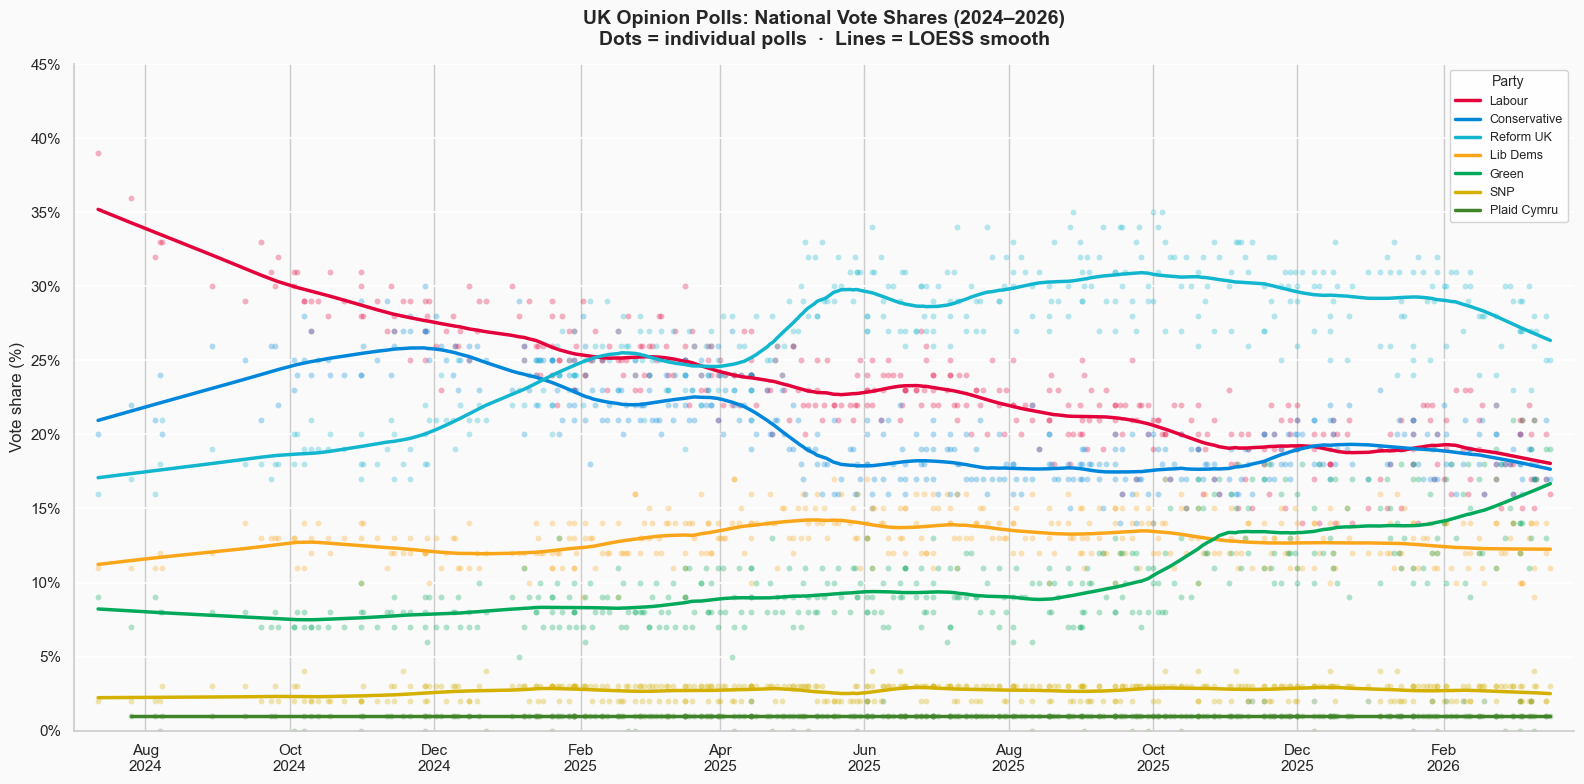

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#FAFAFA")  # off-white background for the whole figure
ax.set_facecolor("#FAFAFA")          # match the axes area

# Convert all dates to matplotlib's internal float format once upfront,
# so we can use them with lowess() which requires numeric x values
date_num = mdates.date2num(df["date"])
years_in_data = sorted(df['date'].dt.year.unique())


for party, colour in PARTY_COLOURS.items():
    # Skip if this party column doesn't exist in the scraped data
    if party not in df.columns:
        continue

    # Build a boolean mask to exclude NaN values for this party
    # (not all pollsters report every party)
    mask    = df[party].notna()
    x_num   = date_num[mask]
    y       = df.loc[mask, party].values
    x_dates = df.loc[mask, "date"].values

    # Skip parties with too few data points for a meaningful smooth
    if len(y) < 5:
        continue

    # ── Scatter: individual poll results ─────────────────────────────────────
    # label="_nolegend_" suppresses these points from the legend;
    # the legend will be driven by the smooth lines below instead
    ax.scatter(x_dates, y, color=colour, alpha=0.30, s=18,
               linewidths=0, label="_nolegend_", zorder=2)

    # ── LOESS smooth ─────────────────────────────────────────────────────────
    # statsmodels lowess() is the Python equivalent of ggplot2's geom_smooth().
    # frac=0.12 means each local regression uses 12% of the data — a relatively
    # narrow bandwidth that follows the trend without over-smoothing.
    # We sort by x first because lowess expects ordered input.
    sort_idx = np.argsort(x_num)
    smoothed = lowess(y[sort_idx], x_num[sort_idx], frac=0.12, return_sorted=True)

    # smoothed[:,0] is x (as floats), smoothed[:,1] is the smoothed y values.
    # We convert x back to datetime objects for the axis to display correctly.
    ax.plot(
        mdates.num2date(smoothed[:, 0]), smoothed[:, 1],
        color=colour, linewidth=2.5,
        label=PARTY_LABELS[party], zorder=3,
    )

# ── Axis formatting ───────────────────────────────────────────────────────────
year_range = f"{min(years_in_data)}–{max(years_in_data)}"

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))        # tick every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))        # 'Aug\n2024' style
ax.set_xlim(df["date"].min() - pd.Timedelta(days=10),
            df["date"].max() + pd.Timedelta(days=10))               # small padding
ax.set_ylim(0, 45)
ax.set_ylabel("Vote share (%)", fontsize=12)
ax.set_title(
    f"UK Opinion Polls: National Vote Shares ({year_range})\n"
    "Dots = individual polls  ·  Lines = LOESS smooth",
    fontsize=14, fontweight="bold", pad=14,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))  # '25%' format
ax.grid(axis="y", color="white", linewidth=1.2, zorder=1)   # subtle white gridlines
ax.spines[["top", "right"]].set_visible(False)               # cleaner look
ax.legend(title="Party", title_fontsize=10, fontsize=9,
          framealpha=0.85, loc="upper right")

plt.tight_layout()
# plt.savefig("uk_opinion_polls.png", dpi=150, bbox_inches="tight") # Uncomment line to save plot
plt.show()


## The Tidy Data Transformation: `pd.melt()`

Before plotting with Seaborn, we need to **reshape** the data from **wide** to **long** format.

**Wide format** (what we have): one column per party
```
date        Lab  Con  Ref  LD   Grn
2024-07-12  39   20   16   11   9
2024-07-26  36   22   17   11   7
```

**Long/tidy format** (what Seaborn wants): one row per observation
```
date        party  vote_share
2024-07-12  Lab    39
2024-07-12  Con    20
2024-07-12  Ref    16
2024-07-26  Lab    36
...
```

This is the **tidy data** principle (Wickham, 2014): each variable is a column, each observation is a row. Once the data is tidy, the `hue` parameter in Seaborn does all the grouping work for us.

In [4]:
# Melt from wide → long using method chaining.
#
# Wide format has one column per party (Lab, Con, Ref, ...).
# Long/tidy format has one row per (date, party) observation.
# Seaborn's hue= parameter expects this long format — it maps a categorical
# column to colour, rather than expecting you to loop over columns yourself.

df_long = (
    df
    .melt(
        id_vars='date',           # keep 'date' as an identifier column
        value_vars=PARTY_COLS,    # unpivot these party columns into rows
        var_name='party',         # new column holding the party abbreviation
        value_name='vote_share'   # new column holding the % value
    )
    .dropna(subset=['vote_share'])   # remove rows where a pollster didn't report that party
    .assign(
        # Add a human-readable label column by mapping abbreviations → full names
        party_label=lambda d: d['party'].map(PARTY_LABELS)
    )
    .sort_values('date')
    .reset_index(drop=True)
)

print(f"Wide shape: {df.shape}  →  Long shape: {df_long.shape}")
df_long.tail(20)


Wide shape: (397, 16)  →  Long shape: (2717, 4)


,date,party,vote_share,party_label
2697,2026-03-16,Con,17.0,Conservative
2698,2026-03-16,Con,21.0,Conservative
2699,2026-03-16,Lab,20.0,Labour
2700,2026-03-16,PC,1.0,Plaid Cymru
2701,2026-03-16,SNP,2.0,SNP
2702,2026-03-16,SNP,2.0,SNP
2703,2026-03-16,PC,1.0,Plaid Cymru
2704,2026-03-16,LD,14.0,Lib Dems
2705,2026-03-16,LD,12.0,Lib Dems
2706,2026-03-16,Ref,28.0,Reform UK


## Approach 2: Seaborn with Melted Long Data

Now the scatter plot is dramatically simpler. By passing `hue='party_label'` to `sns.scatterplot`, Seaborn handles:
- Assigning colours to each party automatically from the `palette` dict
- Iterating over all parties in one call — no loop needed for the scatter

For the LOESS smooth lines we still loop, but the loop body is much cleaner — there is no NaN handling, no date-to-float conversion for the scatter, and no manual colour lookup. All of that is already encoded in the tidy dataframe.

One seaborn-specific wrinkle: `sns.scatterplot` and `ax.plot` don't share a legend system, so we set `legend=False` on the scatter and collect the line artist returned by each `ax.plot` call, then pass those handles to `ax.legend()` manually at the end.

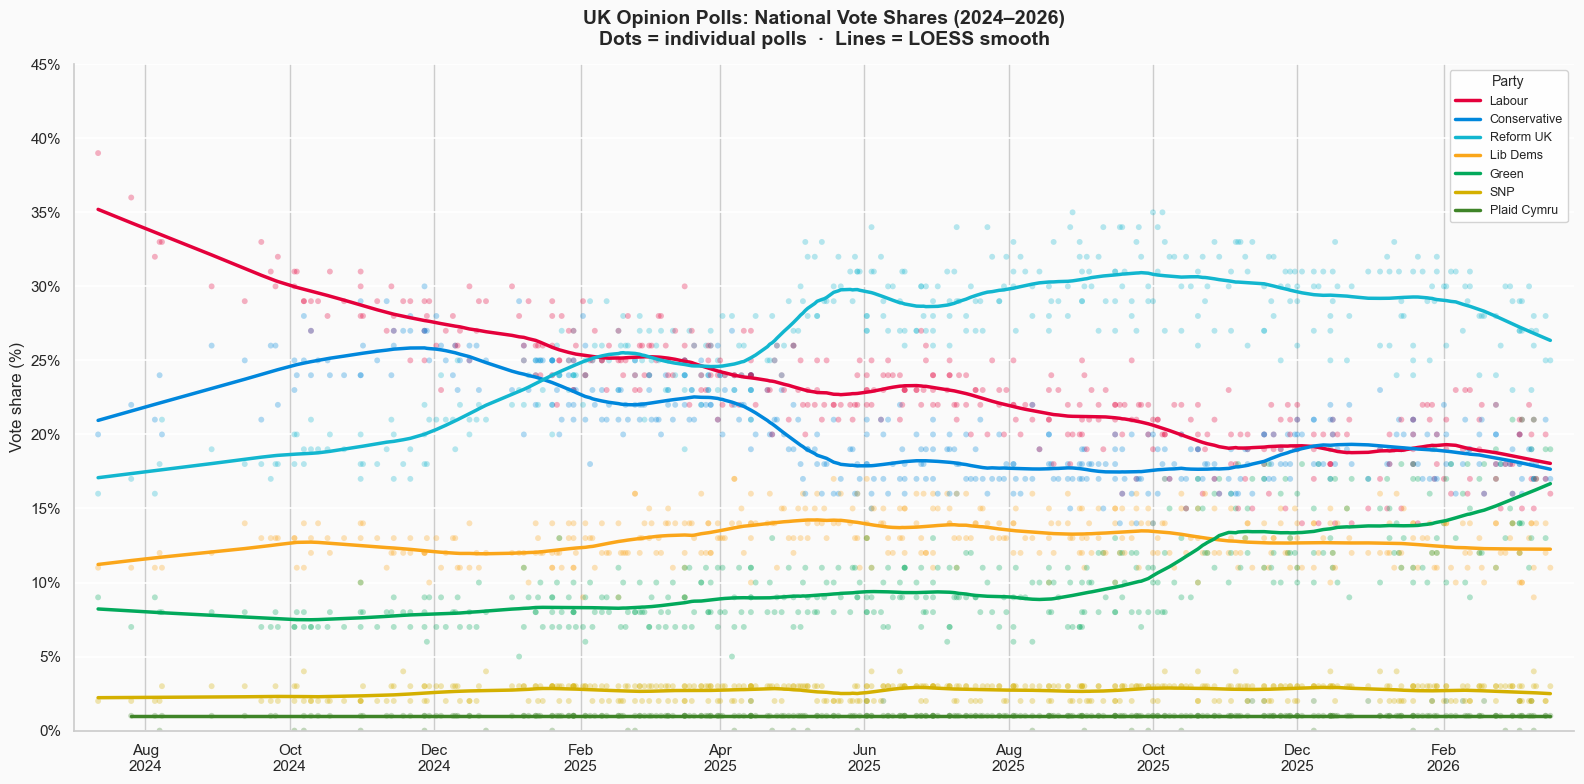

In [9]:
sns.set_theme(style="whitegrid")

# Build a palette dict keyed by full party name (matching party_label column)
palette = {PARTY_LABELS[k]: v for k, v in PARTY_COLOURS.items()}
year_range = f"{min(years_in_data)}–{max(years_in_data)}"

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# ── Scatter: all parties in one call ─────────────────────────────────────────
# hue= maps party_label → colour automatically using the palette dict.
# legend=False here because the legend will be driven by the smooth lines below.
sns.scatterplot(
    data=df_long,
    x="date", y="vote_share",
    hue="party_label",
    palette=palette,
    alpha=0.30, s=18, linewidths=0,
    legend=False,
    ax=ax, zorder=2,
)

# ── LOESS lines + legend handle collection ────────────────────────────────────
# We use statsmodels lowess() directly (rather than sns.regplot(lowess=True))
# because regplot doesn't expose the frac bandwidth parameter.
# ax.plot() returns a list of Line2D objects; the comma unpacks the single item
# so `line` is a Line2D we can pass to ax.legend() later.
legend_handles = []

for party_label, colour in palette.items():
    # Method-chain to filter, clean, and sort in one expression
    subset = (
        df_long
        .query("party_label == @party_label")
        .dropna(subset=["vote_share"])
        .sort_values("date")
    )
    if len(subset) < 5:
        continue

    # Convert dates to floats for lowess, then back to datetimes for the plot
    x_num    = mdates.date2num(subset["date"])
    smoothed = lowess(subset["vote_share"].values, x_num, frac=0.12, return_sorted=True)

    line, = ax.plot(
        mdates.num2date(smoothed[:, 0]), smoothed[:, 1],
        color=colour, linewidth=2.5, zorder=3,
    )
    legend_handles.append((line, party_label))   # store handle + label for legend

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_xlim(df_long["date"].min() - pd.Timedelta(days=10),
            df_long["date"].max() + pd.Timedelta(days=10))
ax.set_ylim(0, 45)
ax.set_xlabel("")
ax.set_ylabel("Vote share (%)", fontsize=12)
ax.set_title(
    f"UK Opinion Polls: National Vote Shares ({year_range})\n"
    "Dots = individual polls  ·  Lines = LOESS smooth",
    fontsize=14, fontweight="bold", pad=14,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.grid(axis="y", color="white", linewidth=1.2, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

# Build the legend from the Line2D handles collected during the loop above.
# We can't use seaborn's auto-legend here because the smooth lines were drawn
# with ax.plot(), which operates outside seaborn's legend machinery.
ax.legend(
    [h for h, _ in legend_handles],
    [l for _, l in legend_handles],
    title="Party", title_fontsize=10, fontsize=9,
    framealpha=0.85, loc="upper right",
)

plt.tight_layout()
# plt.savefig("uk_opinion_polls.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary: Key Differences

| | Matplotlib + `for` loop | Seaborn + `melt` |
|---|---|---|
| **Data shape** | Wide (one column per party) | Long/tidy (one row per observation) |
| **Scatter** | `ax.scatter()` inside a loop | `sns.scatterplot(hue=)` — one call |
| **Colours** | Manually looked up per loop iteration | `hue=` + `palette=` handles it |
| **LOESS smooth** | `statsmodels.lowess()` + `ax.plot()` inside loop | Same — `sns.regplot(lowess=True)` can't accept a custom `frac` |
| **Legend** | Driven by `label=` on `ax.plot()` | Manually built from collected `Line2D` handles |
| **New group?** | Add another loop iteration | Just appears automatically in scatter |
| **Code volume** | More (scatter + smooth fully manual) | Less (scatter is one call; loop is just for LOESS) |

### When to use each

**Matplotlib for loops** give you fine-grained control and are excellent when you need highly customised per-group styling or when each group genuinely needs different treatment.

**Seaborn + tidy data** shines when you have a consistent visual encoding across groups (same geom, same aesthetics, just different colours). The scatter is reduced to a single call, and `hue=` makes the intent of the code immediately readable. The LOESS loop remains, but it is shorter because all the data wrangling has moved into the tidy dataframe.